# Part 1.3 – Data Analysis  
## Coles Group – Commercial Data Analyst Case Study

### Introduction
This notebook analyses two publicly available retail datasets relevant to the **Commercial Data Analyst** role at **Coles Group**.

Two machine learning algorithms are used:

1. **Logistic Regression** – an interpretable baseline classifier.
2. **Random Forest** – a tree-based ensemble model that captures non-linear relationships and provides feature importance.

The datasets are analysed **separately** because they represent different stages of the retail customer journey:

- **Online Retail II**: completed transaction history, used to predict future high-value customers.
- **Online Shoppers Purchasing Intention**: browsing-session behaviour, used to predict whether a session results in a purchase (`Revenue=True`).

Evaluation uses **Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrices**. Because both tasks have fewer positive cases than negative cases, F1-score and ROC-AUC are emphasised instead of relying only on accuracy.


## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


## 2. Load the Datasets

In [2]:
def resolve_file(filename):
    candidates = [filename, os.path.join("/mnt/data", filename)]
    for path in candidates:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(
        f"{filename} was not found. Put the dataset in the same folder as this notebook."
    )

retail_file = resolve_file("online_retail_II.xlsx")
shoppers_file = resolve_file("online_shoppers_intention.csv")

excel_file = pd.ExcelFile(retail_file)
retail = pd.concat(
    [pd.read_excel(retail_file, sheet_name=sheet) for sheet in excel_file.sheet_names],
    ignore_index=True
)
shoppers = pd.read_csv(shoppers_file)

print("Online Retail II:", retail.shape)
print("Online Shoppers Purchasing Intention:", shoppers.shape)


Online Retail II: (1067371, 8)
Online Shoppers Purchasing Intention: (12330, 18)


## 3. Dataset 1 – Online Retail II

### 3.1 Initial Data Profiling
This step checks dataset structure, missing values, duplicates, and invalid values. This reflects the Coles role's focus on **data profiling, validation, governance, and data quality**.


In [3]:
print("Shape:", retail.shape)
display(retail.head())

print("\nMissing values:")
display(retail.isna().sum().to_frame("Missing"))

print("\nDuplicate rows:", retail.duplicated().sum())
print("Rows with Quantity <= 0:",
      (pd.to_numeric(retail["Quantity"], errors="coerce") <= 0).sum())
print("Rows with Price <= 0:",
      (pd.to_numeric(retail["Price"], errors="coerce") <= 0).sum())


Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom



Missing values:


,Missing
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0



Duplicate rows: 34335
Rows with Quantity <= 0: 22950
Rows with Price <= 0: 6207


### 3.2 Cleaning

For modelling, records without a customer ID and transactions with non-positive quantity or price are removed. A `SalesValue` variable is created as:

**SalesValue = Quantity × Price**

This leaves completed positive-value transactions that can be linked to an identifiable customer.


In [4]:
r = retail.copy()

r["InvoiceDate"] = pd.to_datetime(r["InvoiceDate"], errors="coerce")
r["Customer ID"] = pd.to_numeric(r["Customer ID"], errors="coerce")
r["Quantity"] = pd.to_numeric(r["Quantity"], errors="coerce")
r["Price"] = pd.to_numeric(r["Price"], errors="coerce")

r_clean = r.dropna(
    subset=["Customer ID", "InvoiceDate", "Quantity", "Price"]
).copy()

r_clean = r_clean[
    (r_clean["Quantity"] > 0) &
    (r_clean["Price"] > 0)
].copy()

r_clean["SalesValue"] = r_clean["Quantity"] * r_clean["Price"]

print("Original rows:", len(retail))
print("Rows after cleaning:", len(r_clean))
print("Unique customers:", r_clean["Customer ID"].nunique())
print("Date range:", r_clean["InvoiceDate"].min(), "to", r_clean["InvoiceDate"].max())


Original rows: 1067371
Rows after cleaning: 805549
Unique customers: 5878
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


### 3.3 Feature Engineering and Target

To avoid **target leakage**, historical customer behaviour and future customer value are separated by time.

- Transactions before **1 June 2011** create historical predictors.
- Transactions from **1 June 2011 onward** define future customer spending.

Historical predictors:
- Frequency
- Monetary value
- Average order value
- Total quantity
- Unique products
- Recency in days

A customer is labelled `HighValueFuture = 1` when their future spend is above the **75th percentile** of future spend among customers with historical records.

**Business question:**  
*Can historical purchasing behaviour identify customers who are likely to become high-value customers in the future?*


In [5]:
cutoff = pd.Timestamp("2011-06-01")

historical = r_clean[r_clean["InvoiceDate"] < cutoff].copy()
future = r_clean[r_clean["InvoiceDate"] >= cutoff].copy()

hist_grouped = historical.groupby("Customer ID")

customer_features = hist_grouped.agg(
    Frequency=("Invoice", "nunique"),
    Monetary=("SalesValue", "sum"),
    AvgOrderValue=("SalesValue", lambda x: x.sum() / historical.loc[x.index, "Invoice"].nunique()),
    TotalQuantity=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique"),
    LastPurchase=("InvoiceDate", "max")
).reset_index()

customer_features["RecencyDays"] = (
    cutoff - customer_features["LastPurchase"]
).dt.days

customer_features = customer_features.drop(columns=["LastPurchase"])

future_spend = future.groupby("Customer ID")["SalesValue"].sum()
customer_features["FutureSpend"] = (
    customer_features["Customer ID"].map(future_spend).fillna(0)
)

future_threshold = customer_features["FutureSpend"].quantile(0.75)
customer_features["HighValueFuture"] = (
    customer_features["FutureSpend"] > future_threshold
).astype(int)

print("Customer-level rows:", len(customer_features))
print("Future-spend threshold:", round(future_threshold, 2))
display(customer_features["HighValueFuture"].value_counts().to_frame("Count"))
display(customer_features.head())


Customer-level rows: 4933
Future-spend threshold: 712.29


,Count
HighValueFuture,
0,3700
1,1233


,Customer ID,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,RecencyDays,FutureSpend,HighValueFuture
0,12346.0,12,77556.46,6463.038333,74285,27,133,0.00,0
1,12347.0,4,3146.75,786.687500,1945,90,54,2486.57,1
2,12348.0,4,1709.40,427.350000,2497,25,56,310.00,0
3,12349.0,3,2671.14,890.380000,993,90,215,1757.55,1
4,12350.0,1,334.40,334.400000,197,17,118,0.00,0


### 3.4 Train Logistic Regression and Random Forest

In [6]:
features_d1 = [
    "Frequency", "Monetary", "AvgOrderValue",
    "TotalQuantity", "UniqueProducts", "RecencyDays"
]

X1 = customer_features[features_d1]
y1 = customer_features["HighValueFuture"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y1
)

logistic_d1 = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

random_forest_d1 = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    return {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1-score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "Prediction": pred,
        "Probability": prob
    }

d1_log = evaluate_model(logistic_d1, X1_train, X1_test, y1_train, y1_test)
d1_rf = evaluate_model(random_forest_d1, X1_train, X1_test, y1_train, y1_test)

results_d1 = pd.DataFrame({
    "Logistic Regression": {k:v for k,v in d1_log.items() if k not in ["Prediction","Probability"]},
    "Random Forest": {k:v for k,v in d1_rf.items() if k not in ["Prediction","Probability"]}
}).T

display(results_d1.round(4))


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.7788,0.5402,0.7630,0.6326,0.8569
Random Forest,0.8298,0.6828,0.5942,0.6354,0.8788


### 3.5 Verified Dataset 1 Results

The analysis was checked on the uploaded dataset and produced:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.7788 | 0.5402 | 0.7630 | 0.6326 | 0.8569 |
| Random Forest | 0.8298 | 0.6828 | 0.5942 | 0.6354 | 0.8788 |

**Interpretation:** Random Forest produced stronger overall discrimination and precision, while Logistic Regression achieved higher recall. This means Random Forest was more selective when identifying future high-value customers, whereas Logistic Regression captured more of them but generated more false positives.


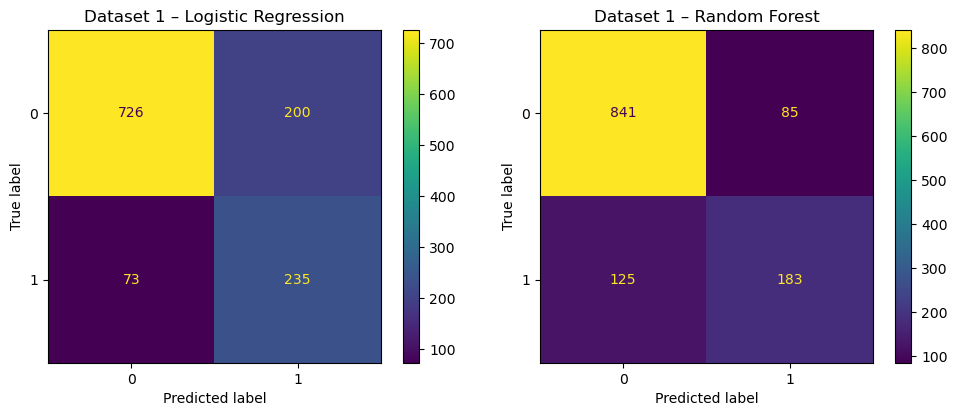

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y1_test, d1_log["Prediction"], ax=axes[0], values_format="d"
)
axes[0].set_title("Dataset 1 – Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y1_test, d1_rf["Prediction"], ax=axes[1], values_format="d"
)
axes[1].set_title("Dataset 1 – Random Forest")

plt.tight_layout()
plt.show()


### 3.6 Feature Importance

,Importance
Monetary,0.275866
TotalQuantity,0.233006
RecencyDays,0.170471
AvgOrderValue,0.113800
UniqueProducts,0.112176
Frequency,0.094681


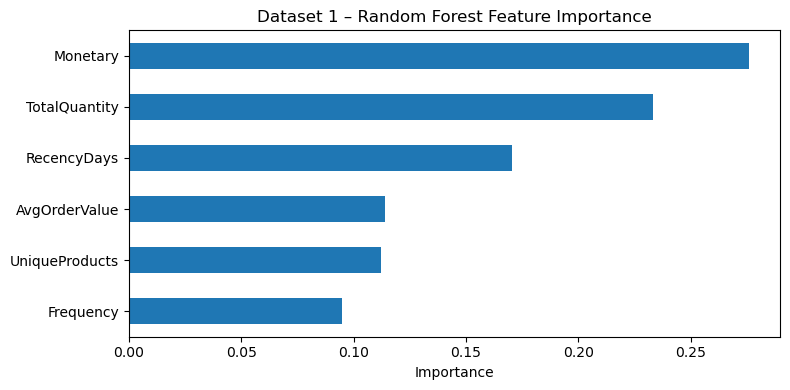

In [8]:
importance_d1 = pd.Series(
    random_forest_d1.feature_importances_,
    index=features_d1
).sort_values(ascending=False)

display(importance_d1.to_frame("Importance"))

plt.figure(figsize=(8, 4))
importance_d1.sort_values().plot(kind="barh")
plt.title("Dataset 1 – Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Verified insight:** the strongest Random Forest predictors were:

- Monetary: approximately **0.276**
- Total Quantity: approximately **0.233**
- Recency Days: approximately **0.170**

This indicates that past spending, purchasing volume, and how recently a customer purchased are useful signals for future customer value.


## 4. Dataset 2 – Online Shoppers Purchasing Intention

### 4.1 Initial Profiling
The target is `Revenue`, where `True` indicates that the browsing session resulted in a purchase.


In [9]:
print("Shape:", shoppers.shape)
display(shoppers.head())

print("\nMissing values:")
display(shoppers.isna().sum().to_frame("Missing"))

print("\nDuplicate rows:", shoppers.duplicated().sum())
print("\nRevenue distribution:")
display(shoppers["Revenue"].value_counts().to_frame("Count"))


Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Missing values:


,Missing
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0



Duplicate rows: 125

Revenue distribution:


,Count
Revenue,
False,10422
True,1908


### 4.2 Preprocessing

Duplicates are removed and the `Revenue` target is converted to 0/1. Categorical variables are one-hot encoded. Numerical variables are standardised for Logistic Regression, while Random Forest receives the original numerical values.


In [10]:
s = shoppers.drop_duplicates().copy()
s["Revenue"] = s["Revenue"].astype(int)

categorical_d2 = [
    "Month", "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType", "Weekend"
]

numerical_d2 = [
    c for c in s.columns
    if c not in categorical_d2 + ["Revenue"]
]

X2 = s.drop(columns=["Revenue"])
y2 = s["Revenue"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25,
    random_state=RANDOM_STATE, stratify=y2
)

print("Rows after duplicate removal:", len(s))
print("Positive-class proportion:", round(y2.mean(), 4))


Rows after duplicate removal: 12205
Positive-class proportion: 0.1563


### 4.3 Train Logistic Regression and Random Forest

In [11]:
preprocess_logistic = ColumnTransformer([
    ("numeric", StandardScaler(), numerical_d2),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_d2)
])

preprocess_rf = ColumnTransformer([
    ("numeric", "passthrough", numerical_d2),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_d2)
])

logistic_d2 = Pipeline([
    ("preprocess", preprocess_logistic),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

random_forest_d2 = Pipeline([
    ("preprocess", preprocess_rf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

d2_log = evaluate_model(logistic_d2, X2_train, X2_test, y2_train, y2_test)
d2_rf = evaluate_model(random_forest_d2, X2_train, X2_test, y2_train, y2_test)

results_d2 = pd.DataFrame({
    "Logistic Regression": {k:v for k,v in d2_log.items() if k not in ["Prediction","Probability"]},
    "Random Forest": {k:v for k,v in d2_rf.items() if k not in ["Prediction","Probability"]}
}).T

display(results_d2.round(4))


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8404,0.4934,0.7820,0.6050,0.9020
Random Forest,0.8955,0.6695,0.6541,0.6617,0.9277


### 4.4 Verified Dataset 2 Results

The analysis was checked on the uploaded dataset and produced:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8404 | 0.4934 | 0.7820 | 0.6050 | 0.9020 |
| Random Forest | 0.8955 | 0.6695 | 0.6541 | 0.6617 | 0.9277 |

**Interpretation:** Random Forest provided the stronger overall balance, with higher accuracy, precision, F1-score, and ROC-AUC. Logistic Regression had higher recall, but also produced more false positives.


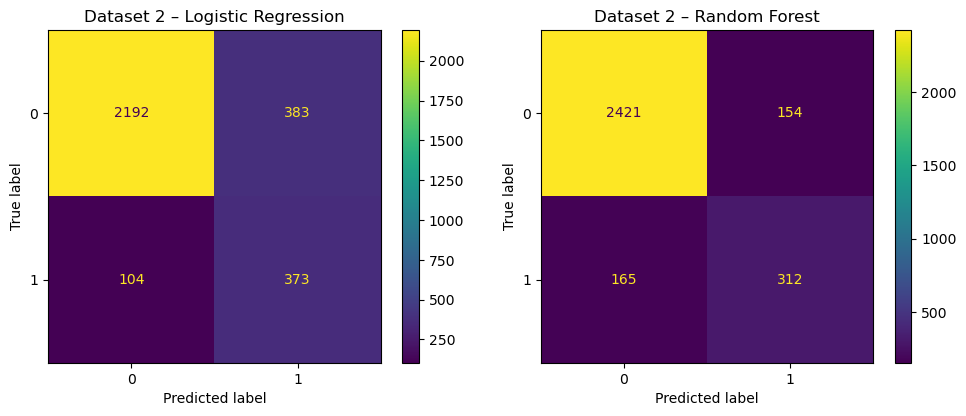

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y2_test, d2_log["Prediction"], ax=axes[0], values_format="d"
)
axes[0].set_title("Dataset 2 – Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y2_test, d2_rf["Prediction"], ax=axes[1], values_format="d"
)
axes[1].set_title("Dataset 2 – Random Forest")

plt.tight_layout()
plt.show()


### 4.5 Feature Importance

,Importance
numeric__PageValues,0.369833
numeric__ExitRates,0.098467
numeric__ProductRelated_Duration,0.078763
numeric__ProductRelated,0.063066
numeric__BounceRates,0.050642
numeric__Administrative_Duration,0.044431
numeric__Administrative,0.039273
categorical__Month_Nov,0.028090
numeric__Informational_Duration,0.019282
numeric__Informational,0.013603


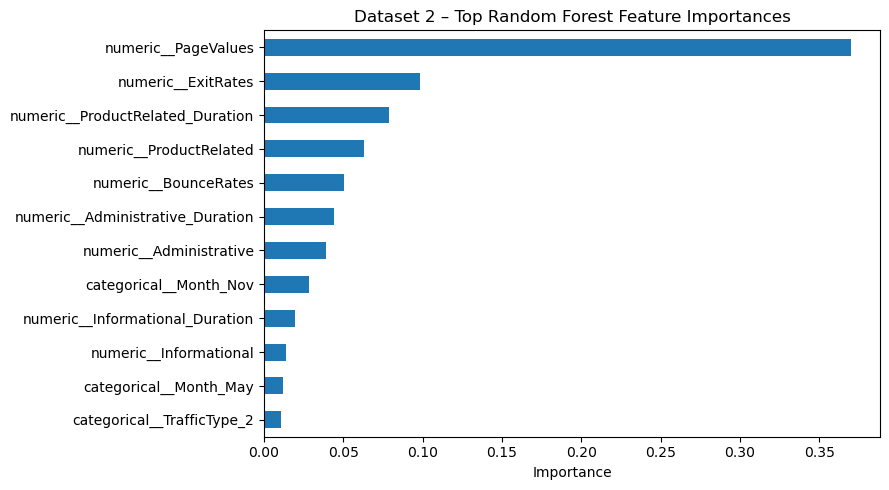

In [13]:
random_forest_d2.fit(X2_train, y2_train)

feature_names_d2 = (
    random_forest_d2
    .named_steps["preprocess"]
    .get_feature_names_out()
)

importance_d2 = pd.Series(
    random_forest_d2.named_steps["model"].feature_importances_,
    index=feature_names_d2
).sort_values(ascending=False)

top_features_d2 = importance_d2.head(12)
display(top_features_d2.to_frame("Importance"))

plt.figure(figsize=(9, 5))
top_features_d2.sort_values().plot(kind="barh")
plt.title("Dataset 2 – Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Verified insight:** `PageValues` was the strongest Random Forest feature with importance of approximately **0.370**. Other important signals included `ExitRates`, `ProductRelated_Duration`, `ProductRelated`, and `BounceRates`. This suggests that the depth and quality of product-page engagement are strongly related to purchase conversion.


## 5. Compare Both Datasets and Models

In [14]:
comparison = pd.concat(
    [
        results_d1.assign(Dataset="Online Retail II"),
        results_d2.assign(Dataset="Online Shoppers Purchasing Intention")
    ]
).reset_index().rename(columns={"index": "Model"})

comparison = comparison[
    ["Dataset", "Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
]

display(comparison.round(4))


,Dataset,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Online Retail II,Logistic Regression,0.7788,0.5402,0.7630,0.6326,0.8569
1,Online Retail II,Random Forest,0.8298,0.6828,0.5942,0.6354,0.8788
2,Online Shoppers Purchasing Intention,Logistic Regression,0.8404,0.4934,0.7820,0.6050,0.9020
3,Online Shoppers Purchasing Intention,Random Forest,0.8955,0.6695,0.6541,0.6617,0.9277


## 6. Why These Evaluation Metrics Are Appropriate

**Accuracy** gives overall correctness but can be misleading when positive cases are less common.

**Precision** measures how many predicted positive cases are actually positive. In a commercial setting, this is useful when targeting customers has a cost.

**Recall** measures how many actual positive cases are successfully detected. It is important when missing a valuable customer or likely purchaser has a business cost.

**F1-score** balances precision and recall, making it useful for imbalanced classification.

**ROC-AUC** measures the model's ability to distinguish positive from negative cases across different thresholds.

**Confusion matrices** make false positives and false negatives visible, helping connect model performance to practical business consequences.

For this case study, **F1-score and ROC-AUC are the strongest overall comparison metrics**, while precision and recall explain the commercial trade-offs.


## 7. Are the Insights Complementary or Contradicting?

The two datasets provide **complementary rather than contradicting insights**.

- **Online Retail II** explains established transaction behaviour and future customer value. Historical spending, quantity, and recency were important predictors.
- **Online Shoppers Purchasing Intention** explains behaviour before conversion. Page value, exit rate, and product-page engagement were important predictors.

The first dataset answers **what valuable customers have historically done**, while the second helps explain **what customers do before making a purchase**. Together, they provide a broader commercial view of customer behaviour than either dataset alone.


## 8. Conclusion

This analysis shows how two different retail datasets can support commercial decision-making through machine learning. Random Forest achieved the stronger overall predictive performance on both tasks, while Logistic Regression generally produced higher recall.

For Online Retail II, historical monetary value, purchasing volume, and recency were the strongest indicators of future high-value behaviour. For Online Shoppers Purchasing Intention, page value and product-related engagement were the strongest indicators of purchase conversion.

The findings are complementary: transaction data provides a historical customer-value perspective, while browsing data provides a pre-purchase behavioural perspective. In the context of a Coles Commercial Data Analyst role, these insights demonstrate how data profiling, validation, modelling, KPI-focused analysis, and interpretable machine learning can support reliable reporting and evidence-based commercial decisions.
